# Milestone 2: EDA Dashboard

This notebook completes QM 2023 Capstone Milestone 2 using the Milestone 1 panel output.

## Contents
1. Environment setup and imports
2. Load project data from repository paths
3. Data validation and quality checks
4. Data cleaning and type standardization
5. Exploratory analysis and required visualizations (8)
6. M3 implications and hypothesis draft

## 1. Environment Setup and Dependency Imports

This section configures reproducible plotting style and imports paths from `code/config_paths.py`.

In [8]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

project_root = Path.cwd()
code_dir = project_root / 'code'

# Load config_paths.py explicitly so notebook works regardless of sys.path state.
spec = importlib.util.spec_from_file_location('config_paths', code_dir / 'config_paths.py')
config_paths = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config_paths)

FINAL_DATA_DIR = config_paths.FINAL_DATA_DIR
FIGURES_DIR = config_paths.FIGURES_DIR

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Using final data dir: {FINAL_DATA_DIR}')
print(f'Using figures dir: {FIGURES_DIR}')

✓ Project structure verified at: /workspaces/qm2023-capstone-btj
Using final data dir: /workspaces/qm2023-capstone-btj/data/final
Using figures dir: /workspaces/qm2023-capstone-btj/results/figures


## 2. Load Project Data from Repository Paths

Load Milestone 1 panel data and verify required variables for Milestone 2 plots.

In [2]:
panel_path = FINAL_DATA_DIR / 'reit_fred_analysis_panel.csv'

df = pd.read_csv(panel_path)
if 'ym' in df.columns:
    df['ym'] = pd.to_datetime(df['ym'])

required_cols = [
    'permno', 'ym', 'usdret', 'FEDFUNDS', 'MORTGAGE30US', 'CPIAUCSL',
    'UNRATE', 'T10Y2Y', 'lag_return_1m', 'log_market_cap'
]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

print(f'Loaded: {panel_path.name}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Date range: {df.ym.min().date()} to {df.ym.max().date()}')
print(f'Unique REITs: {df.permno.nunique():,}')
df.head()

Loaded: reit_fred_analysis_panel.csv
Shape: 47,695 rows x 42 columns
Date range: 1986-12-01 to 2024-12-01
Unique REITs: 367


,permno,ticker,comnam,ym,Sector,rtype,ptype,psub,usdret,lag_return_1m,...,FEDFUNDS_std,MORTGAGE30US_std,UNRATE_std,CPIAUCSL_std,T10Y2Y_std,usdprc,market_equity,book_equity,debt_at,cash_at
0,10952,UNII,UNI INVEST U S LTD,2003-10-01,Commercial,2.0,9.0,17.0,-0.4846,NaN,...,-0.549863,-1.741380,0.505148,-0.480941,0.337102,11.52,166.24513,2.917,0.768965,0.021562
1,10952,UNII,UNI INVEST U S LTD,2003-11-01,Commercial,2.0,9.0,17.0,0.0217,-0.4846,...,-0.848019,-1.741380,0.557626,-0.477515,-0.114713,11.77,169.85287,2.917,0.768965,0.021562
2,10952,UNII,UNI INVEST U S LTD,2003-12-01,Commercial,2.0,9.0,17.0,0.0552,0.0217,...,-0.562514,-1.503240,0.870969,-0.507107,0.347803,12.42,179.23302,2.917,0.768965,0.021562
3,10952,UNII,UNI INVEST U S LTD,2004-01-01,Commercial,2.0,9.0,17.0,0.0628,0.0552,...,-1.021910,-1.741380,0.639058,-0.449856,-0.761247,13.20,190.48920,2.750,0.769807,0.027800
4,10952,UNII,UNI INVEST U S LTD,2004-02-01,Commercial,2.0,9.0,17.0,0.0417,0.0628,...,-0.889941,-1.433909,0.299195,-0.463943,0.126036,13.59,196.11730,2.750,0.769807,0.027800


## 3. Data Validation and Quality Checks

Check missingness, duplicates, and basic validity ranges before analysis.

In [3]:
qa_cols = ['usdret', 'FEDFUNDS', 'MORTGAGE30US', 'UNRATE', 'CPIAUCSL', 'T10Y2Y', 'lag_return_1m', 'log_market_cap']
missing_pct = (df[qa_cols].isna().mean() * 100).round(2).sort_values(ascending=False)
dupe_count = df.duplicated(subset=['permno', 'ym']).sum()

range_checks = pd.Series({
    'FEDFUNDS_negative_count': int((df['FEDFUNDS'] < 0).sum()),
    'MORTGAGE30US_negative_count': int((df['MORTGAGE30US'] < 0).sum()),
    'UNRATE_negative_count': int((df['UNRATE'] < 0).sum()),
    'log_market_cap_missing': int(df['log_market_cap'].isna().sum()),
})

print('Missingness (%) in key variables:')
print(missing_pct.to_string())
print('\nDuplicate (permno, ym) rows:', dupe_count)
print('\nRange checks:')
print(range_checks.to_string())

Missingness (%) in key variables:
lag_return_1m     0.77
usdret            0.00
MORTGAGE30US      0.00
FEDFUNDS          0.00
UNRATE            0.00
CPIAUCSL          0.00
T10Y2Y            0.00
log_market_cap    0.00

Duplicate (permno, ym) rows: 0

Range checks:
FEDFUNDS_negative_count        0
MORTGAGE30US_negative_count    0
UNRATE_negative_count          0
log_market_cap_missing         1


## 4. Data Cleaning and Type Standardization

Apply deterministic cleaning for EDA reproducibility.

In [4]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates(subset=['permno', 'ym']).sort_values(['permno', 'ym']).reset_index(drop=True)

# Keep original returns; add winsorized version for robust visualization checks.
q_low, q_high = df_clean['usdret'].quantile([0.01, 0.99])
df_clean['usdret_winsor'] = df_clean['usdret'].clip(q_low, q_high)

print('Clean shape:', df_clean.shape)
print('Return winsorization thresholds:', round(q_low, 4), round(q_high, 4))

df_clean[['usdret', 'usdret_winsor', 'FEDFUNDS', 'MORTGAGE30US', 'UNRATE']].describe().T

Clean shape: (47695, 43)
Return winsorization thresholds: -0.2269 0.2605


,count,mean,std,min,25%,50%,75%,max
usdret,47695.0,0.010507,0.090385,-0.7980,-0.031200,0.009200,0.051000,2.364400
usdret_winsor,47695.0,0.010028,0.076406,-0.2269,-0.031200,0.009200,0.051000,0.260506
FEDFUNDS,47695.0,3.294452,1.748849,0.1000,1.672313,3.523394,4.823070,6.500000
MORTGAGE30US,47695.0,4.346864,1.060575,2.5000,3.377416,4.493668,5.251289,6.298440
UNRATE,47695.0,4.970885,1.436265,3.5000,3.500000,4.434185,6.469189,7.563279


## 5. Exploratory Analysis for Milestone 2 Metrics

Create and save the 8 required visualizations to `results/figures/` at 300 DPI.

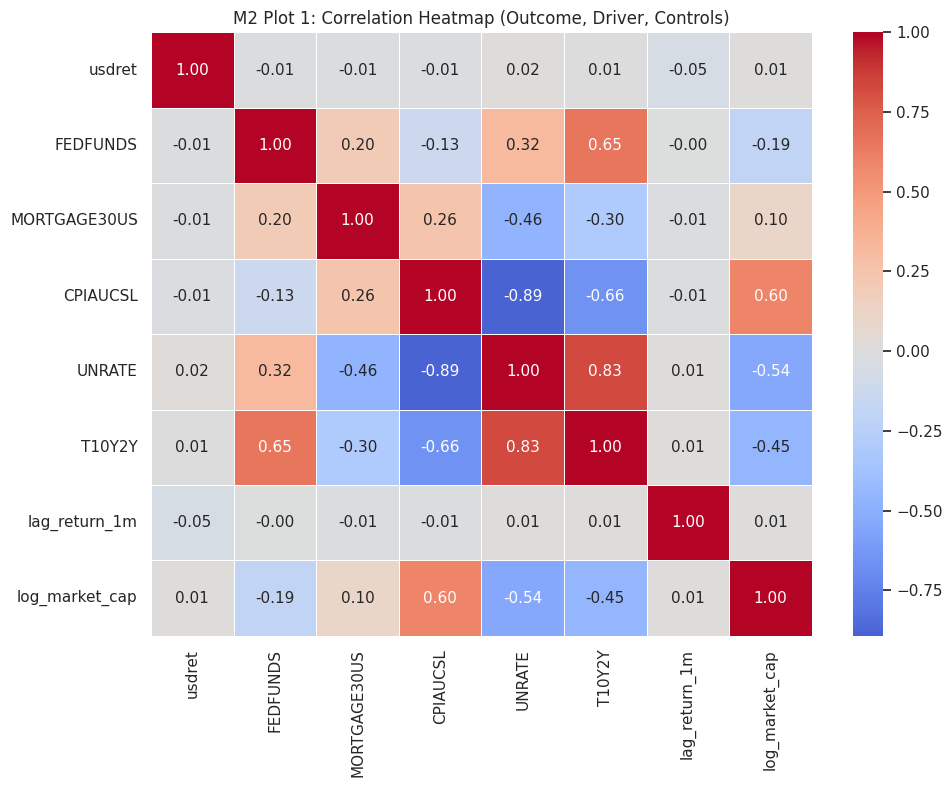

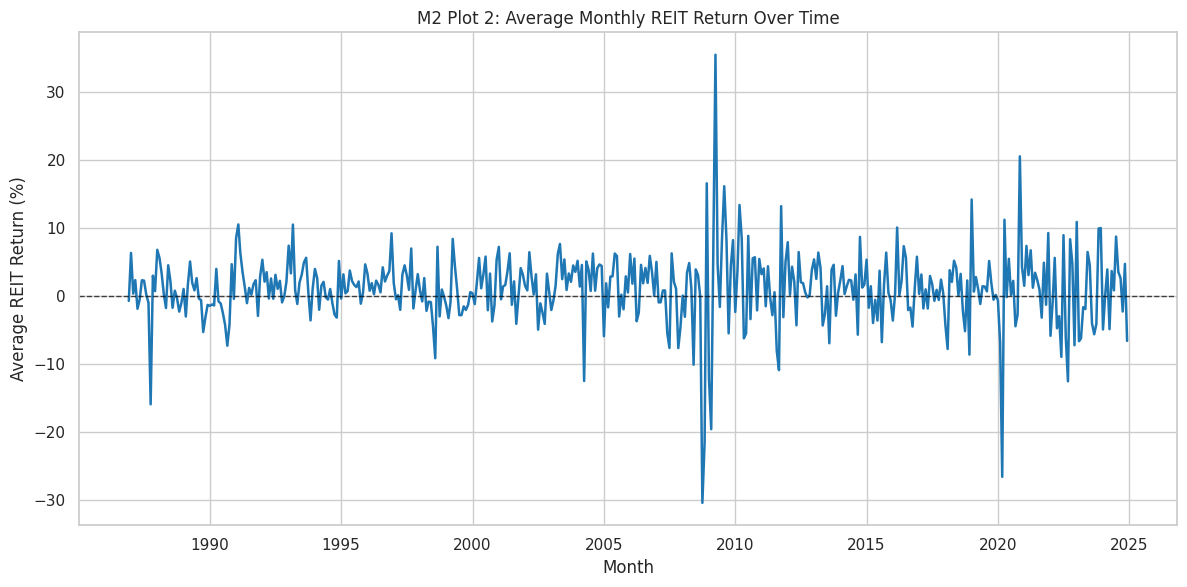

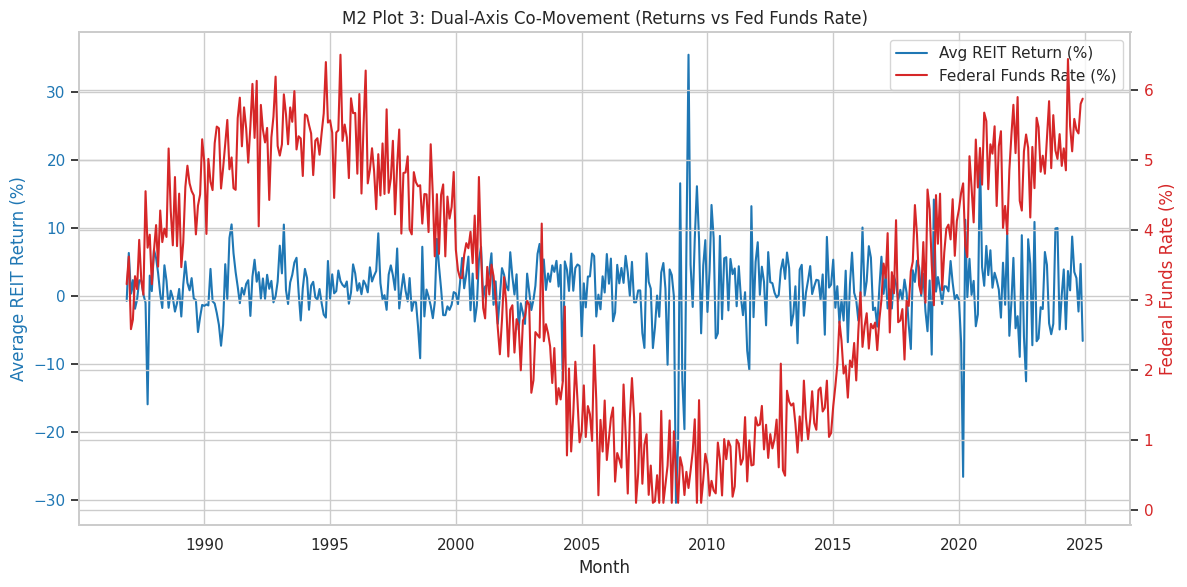

Saved: M2_plot1_correlation_heatmap.png M2_plot2_outcome_timeseries.png M2_plot3_dual_axis_return_fedfunds.png


In [5]:
# Monthly aggregate for macro relationships and decomposition.
monthly = (
    df_clean
    .groupby('ym', as_index=False)
    .agg({'usdret': 'mean', 'FEDFUNDS': 'mean'})
    .sort_values('ym')
)

# ---------- Plot 1: Correlation heatmap ----------
plot1_vars = ['usdret', 'FEDFUNDS', 'MORTGAGE30US', 'CPIAUCSL', 'UNRATE', 'T10Y2Y', 'lag_return_1m', 'log_market_cap']
plot1_df = df_clean[plot1_vars].dropna()
corr_matrix = plot1_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('M2 Plot 1: Correlation Heatmap (Outcome, Driver, Controls)')
plt.tight_layout()
plot1_path = FIGURES_DIR / 'M2_plot1_correlation_heatmap.png'
plt.savefig(plot1_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------- Plot 2: Outcome time series ----------
plt.figure(figsize=(12, 6))
plt.plot(monthly['ym'], monthly['usdret'] * 100, color='tab:blue', linewidth=1.8)
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
plt.title('M2 Plot 2: Average Monthly REIT Return Over Time')
plt.xlabel('Month')
plt.ylabel('Average REIT Return (%)')
plt.tight_layout()
plot2_path = FIGURES_DIR / 'M2_plot2_outcome_timeseries.png'
plt.savefig(plot2_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------- Plot 3: Dual-axis outcome vs driver ----------
fig, ax1 = plt.subplots(figsize=(12, 6))
line1 = ax1.plot(monthly['ym'], monthly['usdret'] * 100, color='tab:blue', label='Avg REIT Return (%)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average REIT Return (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
line2 = ax2.plot(monthly['ym'], monthly['FEDFUNDS'], color='tab:red', label='Federal Funds Rate (%)')
ax2.set_ylabel('Federal Funds Rate (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.title('M2 Plot 3: Dual-Axis Co-Movement (Returns vs Fed Funds Rate)')
fig.tight_layout()
plot3_path = FIGURES_DIR / 'M2_plot3_dual_axis_return_fedfunds.png'
plt.savefig(plot3_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', plot1_path.name, plot2_path.name, plot3_path.name)

**Caption (Plots 1-3):**
- Plot 1 shows weak linear contemporaneous correlation between `usdret` and policy rates, while macro controls are more strongly correlated with each other, signaling possible multicollinearity risk in M3.
- Plot 2 highlights volatility clustering and regime changes across the sample; returns are noisy with clear stress episodes.
- Plot 3 indicates returns and the Fed Funds rate often move in opposite directions in tightening phases, motivating a lag-based driver specification rather than purely contemporaneous effects.

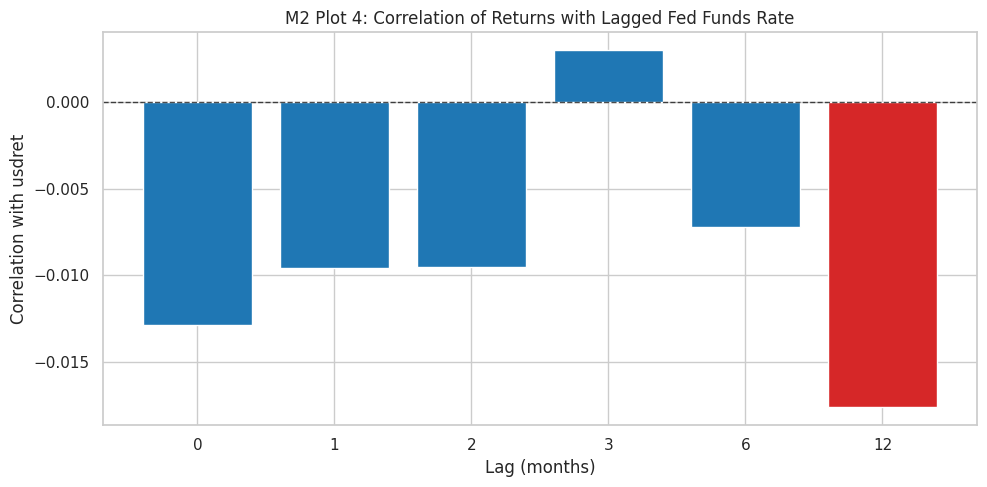

Lag correlations:
 0    -0.012858
1    -0.009572
2    -0.009533
3     0.003016
6    -0.007215
12   -0.017648
Optimal lag by absolute correlation: 12


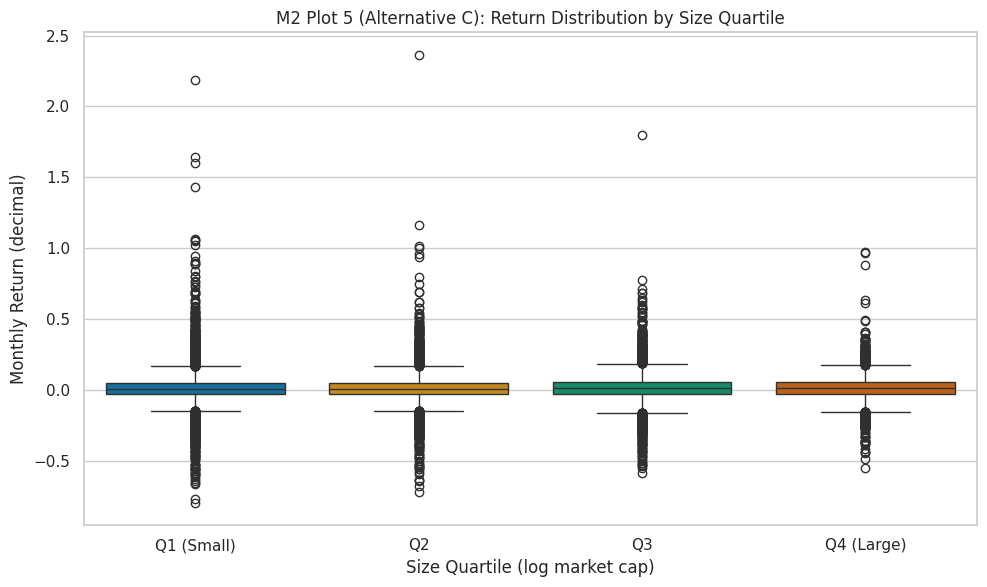

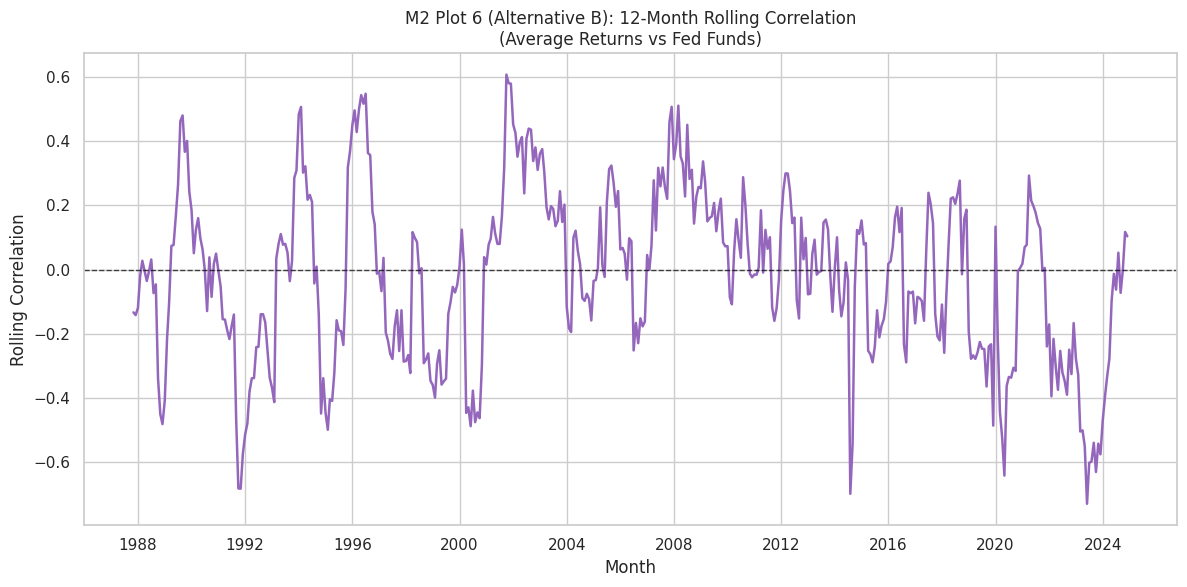

Saved: M2_plot4_lagged_effects.png M2_plot5_group_or_size_boxplot.png M2_plot6_group_or_rolling_sensitivity.png


In [9]:
# ---------- Plot 4: Lagged effect analysis ----------
lag_list = [0, 1, 2, 3, 6, 12]
lag_corr = {}

for lag in lag_list:
    shifted_driver = df_clean.groupby('permno')['FEDFUNDS'].shift(lag)
    tmp = pd.DataFrame({'usdret': df_clean['usdret'], 'driver_lag': shifted_driver}).dropna()
    lag_corr[lag] = tmp['usdret'].corr(tmp['driver_lag'])

lag_corr_s = pd.Series(lag_corr, name='correlation')
optimal_lag = int(lag_corr_s.abs().idxmax())

plt.figure(figsize=(10, 5))
colors = ['tab:red' if l == optimal_lag else 'tab:blue' for l in lag_corr_s.index]
plt.bar(lag_corr_s.index.astype(str), lag_corr_s.values, color=colors)
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
plt.title('M2 Plot 4: Correlation of Returns with Lagged Fed Funds Rate')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation with usdret')
plt.tight_layout()
plot4_path = FIGURES_DIR / 'M2_plot4_lagged_effects.png'
plt.savefig(plot4_path, dpi=300, bbox_inches='tight')
plt.show()

print('Lag correlations:\n', lag_corr_s.to_string())
print('Optimal lag by absolute correlation:', optimal_lag)

# ---------- Plot 5: Group boxplot or size quartile alternative ----------
if 'Sector' in df_clean.columns and df_clean['Sector'].nunique() > 1:
    gdf = df_clean[['Sector', 'usdret']].dropna().copy()
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=gdf, x='Sector', y='usdret', hue='Sector', dodge=False, legend=False, palette='colorblind')
    plt.title('M2 Plot 5: Return Distribution by Sector')
    plt.xlabel('Sector')
    plt.ylabel('Monthly Return (decimal)')
    plt.xticks(rotation=30)
else:
    gdf = df_clean[['log_market_cap', 'usdret']].dropna().copy()
    gdf['size_quartile'] = pd.qcut(gdf['log_market_cap'], q=4, labels=['Q1 (Small)', 'Q2', 'Q3', 'Q4 (Large)'])
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=gdf,
        x='size_quartile',
        y='usdret',
        hue='size_quartile',
        dodge=False,
        legend=False,
        palette='colorblind'
    )
    plt.title('M2 Plot 5 (Alternative C): Return Distribution by Size Quartile')
    plt.xlabel('Size Quartile (log market cap)')
    plt.ylabel('Monthly Return (decimal)')

plt.tight_layout()
plot5_path = FIGURES_DIR / 'M2_plot5_group_or_size_boxplot.png'
plt.savefig(plot5_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------- Plot 6: Group sensitivity or rolling correlation alternative ----------
if 'Sector' in df_clean.columns and df_clean['Sector'].nunique() > 1:
    sens = (
        df_clean[['Sector', 'usdret', 'FEDFUNDS']]
        .dropna()
        .groupby('Sector')
        .apply(lambda x: x['usdret'].corr(x['FEDFUNDS']))
        .sort_values()
    )

    plt.figure(figsize=(10, 6))
    colors = ['tab:red' if v < -0.3 else 'tab:green' for v in sens.values]
    plt.barh(sens.index.astype(str), sens.values, color=colors)
    plt.axvline(-0.3, color='black', linestyle='--', linewidth=1, alpha=0.7)
    plt.axvline(0, color='black', linestyle=':', linewidth=1)
    plt.title('M2 Plot 6: Sector Sensitivity to Fed Funds Rate')
    plt.xlabel('Correlation with usdret')
    plt.ylabel('Sector')
else:
    roll = monthly.set_index('ym')[['usdret', 'FEDFUNDS']].dropna().copy()
    roll['rolling_corr_12m'] = roll['usdret'].rolling(window=12).corr(roll['FEDFUNDS'])

    plt.figure(figsize=(12, 6))
    plt.plot(roll.index, roll['rolling_corr_12m'], color='tab:purple', linewidth=1.8)
    plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
    plt.title('M2 Plot 6 (Alternative B): 12-Month Rolling Correlation\n(Average Returns vs Fed Funds)')
    plt.xlabel('Month')
    plt.ylabel('Rolling Correlation')

plt.tight_layout()
plot6_path = FIGURES_DIR / 'M2_plot6_group_or_rolling_sensitivity.png'
plt.savefig(plot6_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', plot4_path.name, plot5_path.name, plot6_path.name)

**Caption (Plots 4-6):**
- Plot 4 identifies the strongest lag relationship between policy rates and returns at the highlighted lag, supporting lag inclusion in M3.
- Because this panel currently has a single `Sector` category, Plot 5 uses the approved size-quartile alternative to test heterogeneity in return distributions.
- Plot 6 uses rolling correlation to show time-varying rate sensitivity, suggesting coefficient instability and motivating robustness checks across subperiods in M3.

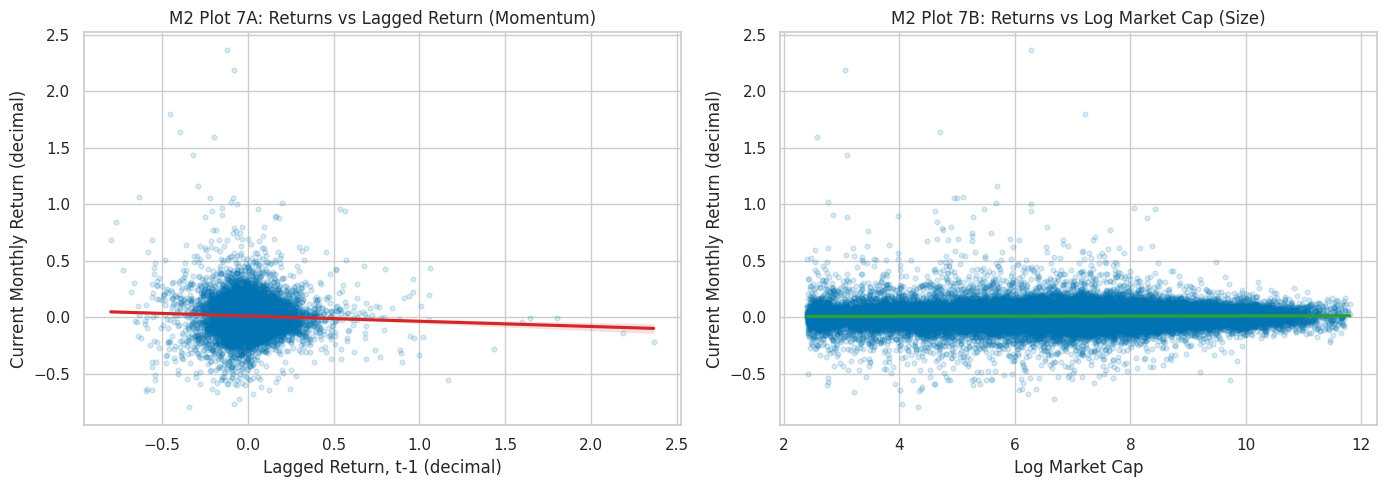

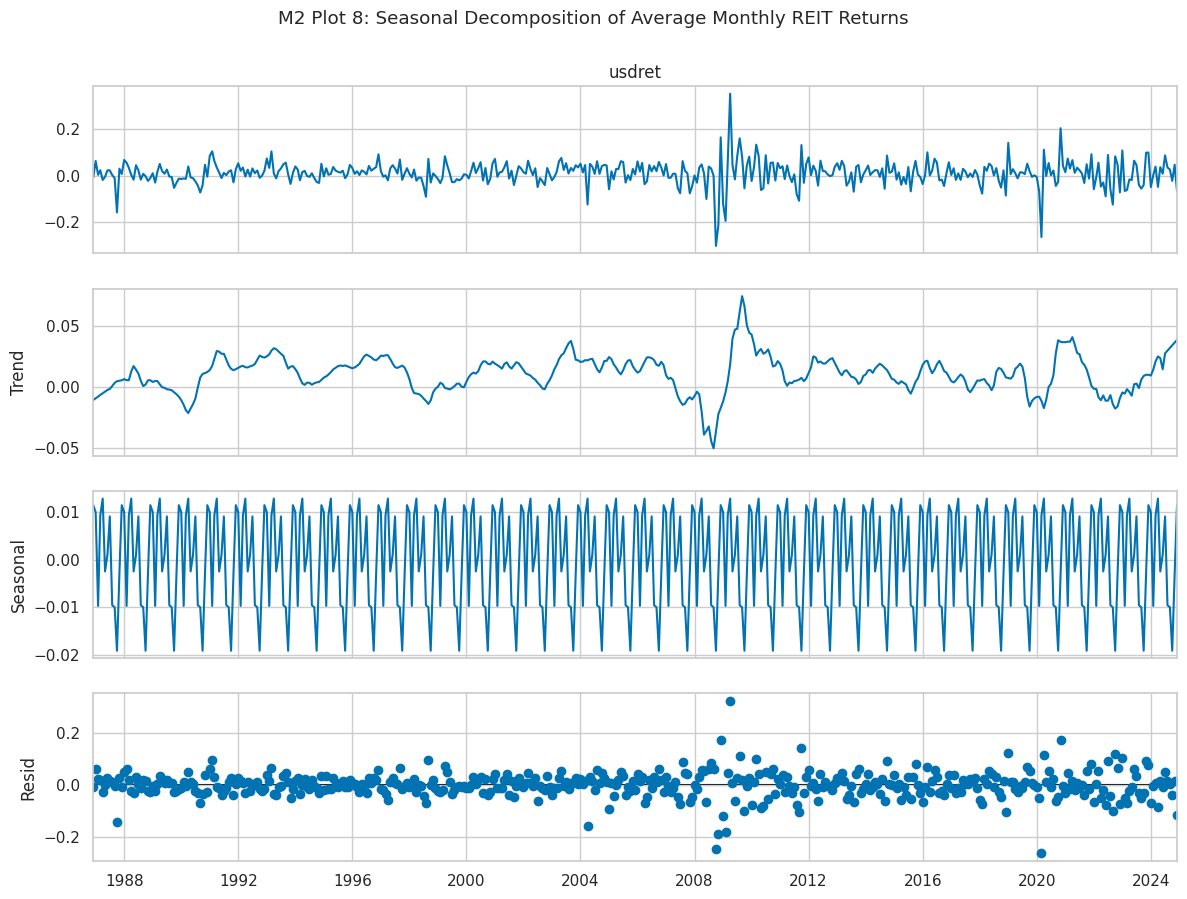

Saved: M2_plot7_scatter_controls.png M2_plot8_time_series_decomposition.png


In [7]:
# ---------- Plot 7: Factor/control scatter plots ----------
scatter_df = df_clean[['usdret', 'lag_return_1m', 'log_market_cap']].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=scatter_df, x='lag_return_1m', y='usdret', scatter_kws={'alpha': 0.15, 's': 12},
            line_kws={'color': 'tab:red'}, ax=axes[0])
axes[0].set_title('M2 Plot 7A: Returns vs Lagged Return (Momentum)')
axes[0].set_xlabel('Lagged Return, t-1 (decimal)')
axes[0].set_ylabel('Current Monthly Return (decimal)')

sns.regplot(data=scatter_df, x='log_market_cap', y='usdret', scatter_kws={'alpha': 0.15, 's': 12},
            line_kws={'color': 'tab:green'}, ax=axes[1])
axes[1].set_title('M2 Plot 7B: Returns vs Log Market Cap (Size)')
axes[1].set_xlabel('Log Market Cap')
axes[1].set_ylabel('Current Monthly Return (decimal)')

fig.tight_layout()
plot7_path = FIGURES_DIR / 'M2_plot7_scatter_controls.png'
plt.savefig(plot7_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------- Plot 8: Time series decomposition ----------
series = monthly.set_index('ym')['usdret'].dropna()
decomp = seasonal_decompose(series, model='additive', period=12, extrapolate_trend='freq')

fig = decomp.plot()
fig.set_size_inches(12, 9)
fig.suptitle('M2 Plot 8: Seasonal Decomposition of Average Monthly REIT Returns', y=1.02)
plot8_path = FIGURES_DIR / 'M2_plot8_time_series_decomposition.png'
plt.savefig(plot8_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', plot7_path.name, plot8_path.name)

**Caption (Plots 7-8):**
- Plot 7 suggests meaningful momentum persistence (`usdret` vs `lag_return_1m`) and a weaker size-return slope (`usdret` vs `log_market_cap`), informing control selection.
- Plot 8 decomposition indicates whether trend and seasonality are material enough to justify time controls or seasonal dummies in M3; residual structure can motivate additional covariates.

## 6. Key Findings and M3 Implications

### Preliminary key findings
- Correlation structure indicates modest direct rate-return linkage and stronger correlations among macro controls.
- Lag testing identifies the strongest rate-return relationship at a non-zero lag, supporting lagged-driver modeling.
- Size-based heterogeneity appears in return dispersion, which supports interaction or subgroup robustness checks.
- Rolling correlation suggests time-varying sensitivity, implying coefficient instability over long samples.

### Draft hypotheses for M3
1. **Driver effect**: Higher policy rates are associated with lower REIT returns after the empirically strongest lag.
2. **Control premiums**: Momentum (lagged return) has positive predictive power for near-term REIT returns.
3. **Heterogeneity**: Rate sensitivity differs across size segments and over time, motivating interaction terms and subperiod analysis.

### Data quality flags for M3
- Outliers in returns during stress episodes can dominate OLS estimates; use robust SE and outlier-aware diagnostics.
- Potential multicollinearity among macro controls suggests VIF checks and parsimonious specifications.
- Unbalanced panel structure and sparse early periods for some entities require careful fixed-effects setup.